# phase1_ingestion
Execute the cell below to run the code and save outputs directly into this notebook.

=== Phase 1: Data Ingestion & Directory Mapping ===
Loading dataset from: d:\heart_disease\dataset\mit-bih-arrhythmia-database-1.0.0
Found 48 records in standard PhysioNet format.

--- Quick Peek into Record 100 ---
Signal Length: 650000 samples, Sampling Rate: 360 Hz
Annotation Types Count in this record:
  Type '+': 1
  Type 'N': 2239
  Type 'A': 33
  Type 'V': 1

Extracted one Normal (N) at sample 370
Extracted one Arrhythmia (A) at sample 2044

Saved comparison plot to 'd:\heart_disease\phase1_plot.png'.


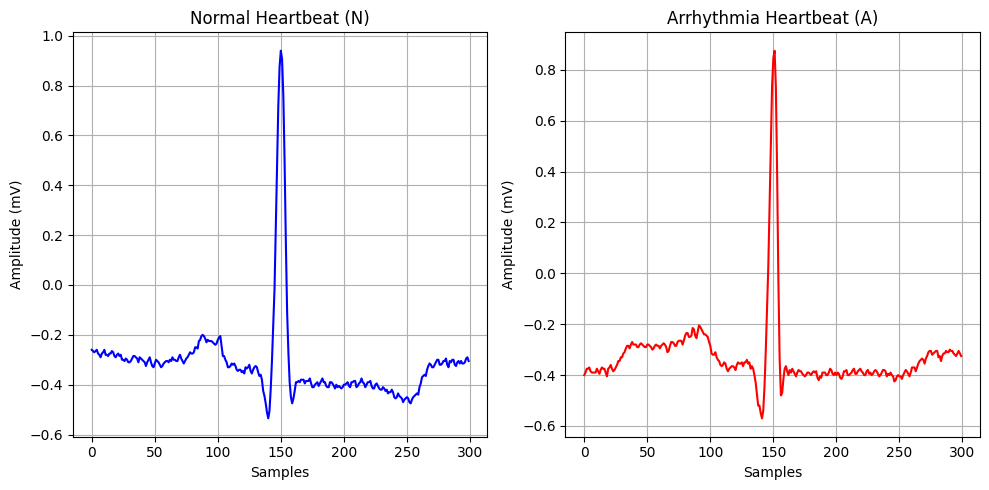

In [2]:
import os
import wfdb
import matplotlib.pyplot as plt

def main():
    # Setup paths
    dataset_path = r'd:\heart_disease\dataset\mit-bih-arrhythmia-database-1.0.0'
    
    # 1. Environment and Path Checks
    print("=== Phase 1: Data Ingestion & Directory Mapping ===")
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset not found at {dataset_path}")
        return
        
    print(f"Loading dataset from: {dataset_path}")
    
    # Get all record names (e.g. '100', '101')
    records = set([f.split('.')[0] for f in os.listdir(dataset_path) if f.endswith('.hea')])
    records = sorted(list(records))
    print(f"Found {len(records)} records in standard PhysioNet format.\n")
    
    # 2. Extract Data and Annotations (We'll check record 100 for a demonstration)
    record_name = records[0]
    record_path = os.path.join(dataset_path, record_name)
    
    try:
        # Load the physical signal and annotations
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        sig = record.p_signal[:, 0] # Use MLII (first channel)
        labels = annotation.symbol
        samples = annotation.sample
    except Exception as e:
        print(f"Error loading record {record_name}: {e}")
        return

    # Count samples per class in just this specific file (as a quick peek)
    from collections import Counter
    class_counts = Counter(labels)
    print(f"--- Quick Peek into Record {record_name} ---")
    print(f"Signal Length: {len(sig)} samples, Sampling Rate: {record.fs} Hz")
    print("Annotation Types Count in this record:")
    for label, count in class_counts.items():
        print(f"  Type '{label}': {count}")
    
    # 3. Plotting One Normal vs. One Arrhythmia heartbeat
    # Usually 'N' is normal. Let's find one 'N' and one non-'N' (e.g. 'V', 'A', etc.)
    normal_idx = None
    arrhythmia_idx = None
    
    for i, symbol in enumerate(labels):
        if symbol == 'N' and normal_idx is None:
            # ensure it's not too close to the beginning/end
            if samples[i] > 150 and samples[i] < len(sig) - 150:
                normal_idx = samples[i]
        elif symbol in ['V', 'S', 'A', 'F', 'R', 'L'] and arrhythmia_idx is None:
            if samples[i] > 150 and samples[i] < len(sig) - 150:
                arrhythmia_idx = samples[i]
                arrhythmia_type = symbol
                
        if normal_idx is not None and arrhythmia_idx is not None:
            break
            
    if normal_idx is None or arrhythmia_idx is None:
        print("Couldn't find both a Normal and Arrhythmia sample cleanly in this record.")
        return
        
    print(f"\nExtracted one Normal (N) at sample {normal_idx}")
    print(f"Extracted one Arrhythmia ({arrhythmia_type}) at sample {arrhythmia_idx}")
    
    # Extract windows centered at the peak. 300 samples total
    window = 150 
    
    normal_signal = sig[normal_idx - window : normal_idx + window]
    arrhythmia_signal = sig[arrhythmia_idx - window : arrhythmia_idx + window]
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(normal_signal, color='blue')
    plt.title("Normal Heartbeat (N)")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(arrhythmia_signal, color='red')
    plt.title(f"Arrhythmia Heartbeat ({arrhythmia_type})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(r'd:\heart_disease\phase1_plot.png')
    print("\nSaved comparison plot to 'd:\\heart_disease\\phase1_plot.png'.")
    plt.show()

if __name__ == '__main__':
    main()

